# Load a MTRX image for Analysis
Use this notebook to load Scienta Omicron Matrix format SPM data. Your own code can be added to process the data. 

**Author**: Steven R. Schofield  
**Created**: April, 2026

In [17]:
# For file path operations
import os

In [18]:
# Path to data processing module
module_path_list = [
    '/Users/steven/academic-iCloud/Python/modules'        # CHANGE THIS TO YOUR OWN PATH WHERE YOU KEEP THESE PYTHON MODULES
] 

module_path = next((p for p in module_path_list if os.path.exists(p)), None)
if not module_path:
    exit("No valid module paths.")
else:
    print('module_path = {}'.format(module_path))
    print(os.listdir(module_path))

module_path = /Users/steven/academic-iCloud/Python/modules
['SRSML24', '.DS_Store', 'SRSCALCUTILS', 'SCT25']


In [19]:
# # Ensure modules are reloaded 
%load_ext autoreload
%autoreload 2

# Import standard modules
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps  # Import the new colormap module

from natsort import natsorted

# Add custom module path to list
sys.path.append(module_path)

# Import custom module
import SRSML24.data_prep as dp
import SRSML24.data_analysis as da

start_time = dp.current_datetime()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current time 2026-04-28 07:59:59


In [20]:
# The working direcroryt should contain a subfolder 'mtrx' that contains the matrix image data. They can be in subfolders
working_directory = '/Users/steven/Python-data-Hardeep/03-Oct-2025'      # CHANGE THIS TO YOUR OWN PATH WHERE YOU KEEP YOUR MTRX DATA
output_directory = os.path.join(working_directory, 'output')

In [21]:
job_data_path = dp.create_new_data_path(working_directory, output_directory, include_date=False)
mtrx_path = dp.create_new_data_path(working_directory, 'mtrx', include_date=False)

if not working_directory:
    exit("No valid data paths.")
else:
    print('Top   : {}'.format(working_directory))
    print('Read  : {}'.format(mtrx_path))
    print('Write : {}'.format(job_data_path))

Top   : /Users/steven/Python-data-Hardeep/03-Oct-2025
Read  : /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx
Write : /Users/steven/Python-data-Hardeep/03-Oct-2025/output


In [22]:
# Training data
mtrx_file_list, _ = dp.list_files_by_extension(mtrx_path,'Z_mtrx',verbose=False)

Found 350 files with extension 'Z_mtrx' in directory:
/Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx


In [23]:
mtrx_file_list = natsorted(mtrx_file_list)  
for i, file in enumerate(mtrx_file_list):
    print(i, file)

0 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--1_1.Z_mtrx
1 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--2_1.Z_mtrx
2 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--3_1.Z_mtrx
3 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--4_1.Z_mtrx
4 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--5_1.Z_mtrx
5 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--6_1.Z_mtrx
6 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--7_1.Z_mtrx
7 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--8_1.Z_mtrx
8 /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--9_1.Z_mtrx
9

In [30]:
mtrx_file = mtrx_file_list[292]
print('Working with image: {}'.format(mtrx_file))


Working with image: /Users/steven/Python-data-Hardeep/03-Oct-2025/mtrx/default_2025Oct03-085731_STM-STM_Spectroscopy--176_1.Z_mtrx


'default_2025Oct03-085731_STM-STM_Spectroscopy--176_1' — 4 scan directions loaded: FU, BU, FD, BD


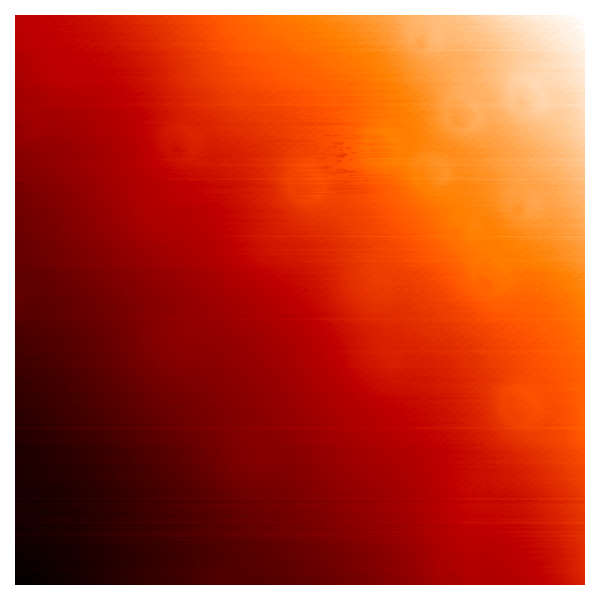

In [31]:
imgFU, imgBU, imgFD, imgBD, metadata = dp.load_image_for_processing(mtrx_file)

dp.display_image(imgFU,cmap='gist_heat')

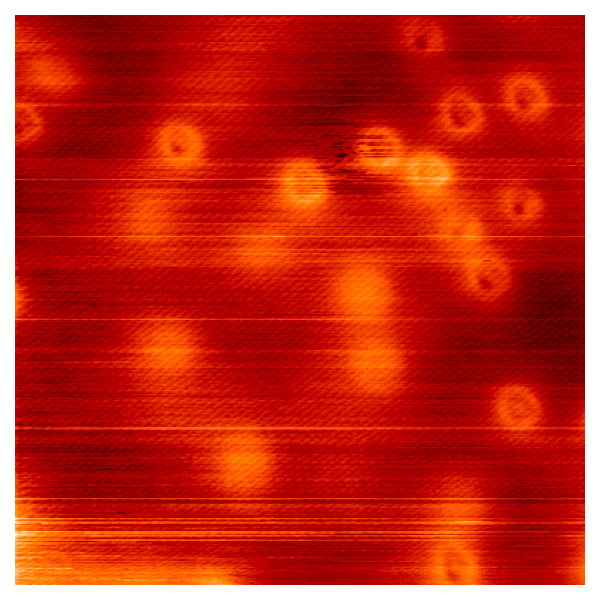

In [32]:
#imgFU_flat = dp.flatten_image_data(imgFU, flatten_method='poly_xy')
imgFU_flat = dp.flatten_image_data(imgFU, flatten_method='iterate_mask')  # default
#imgFU_flat = dp.flatten_image_data(imgFU, flatten_method='row_mean')
#imgFU_flat = dp.flatten_image_data(imgFU, flatten_method='row_mean_and_slope')

dp.display_image(imgFU_flat,cmap='gist_heat')

pixel_size_from_metadata: 100 nm / 400 px = 0.2500 nm/px
pick_and_profile ready.
  Click the image to set the centre point.
  Arrow keys nudge the centre by 1 pixel.
  Press 's' to save the current profile.
  Profiles accumulate in result['saved'].
  When done: radii, profiles = da.stack_profiles(result['saved'])


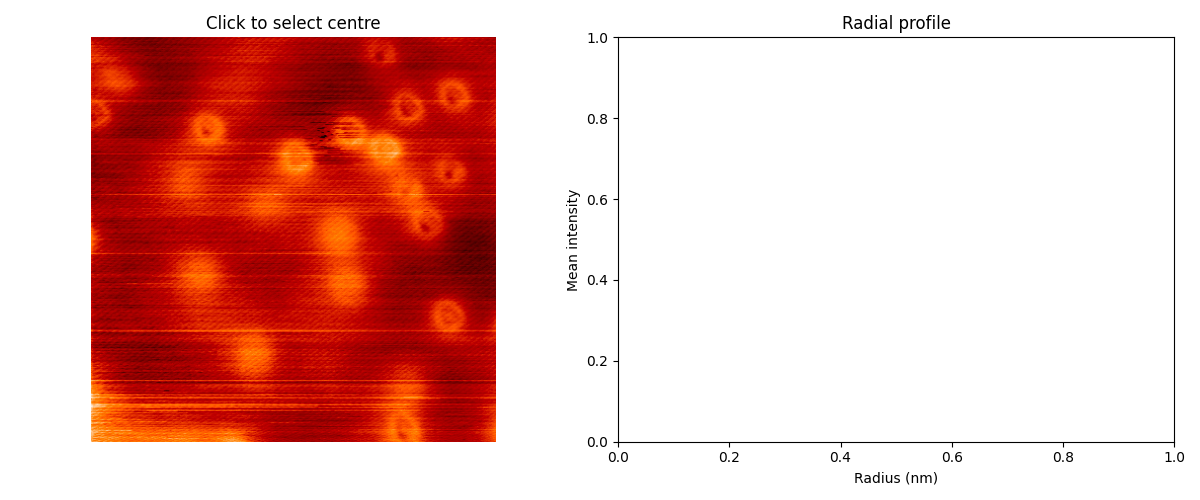

In [33]:
%matplotlib widget
pixel_size = da.pixel_size_from_metadata(imgFU, metadata)
result = da.pick_and_profile(imgFU_flat, cmap='gist_heat',  pixel_size=pixel_size)

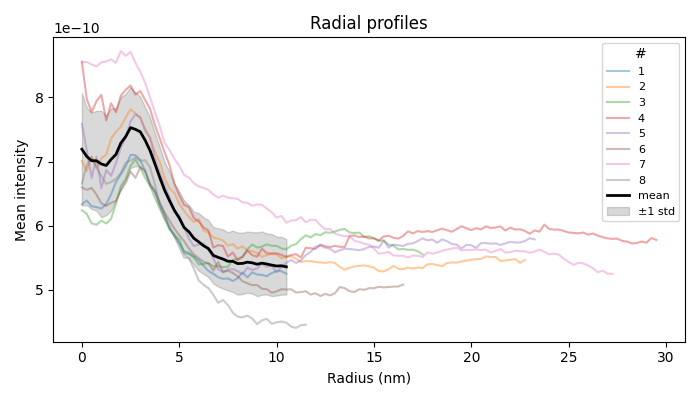

In [36]:
radii, profiles = da.stack_profiles(result['saved'])
fig, ax = da.plot_profiles(radii, profiles)

In [ ]:
p_mean = np.nanmean(profiles, axis=0)
r_mean = np.nanmean(radii, axis=0)
fig, ax = da.plot_profiles(r_mean, p_mean)  